# LAB 02: THỰC HÀNH IMAGE FILTER

In [2]:
import cv2
import matplotlib.pyplot as TranDaiPhat

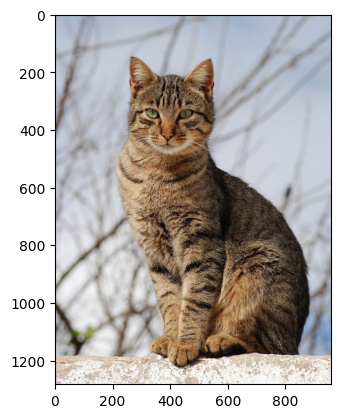

In [4]:
img = cv2.imread('cat.jpg')
img = img[:,:,::-1]
TranDaiPhat.imshow(img)


## 1. Sử dụng boxFilter: cv2.blur() hoặc cv2.boxFilter() để làm mờ ảnh (sử dụng nhiều thông số filter khác nhau), biểu diễn ảnh gốc và ảnh làm mờ cùng nhau để kiểm chứng.  

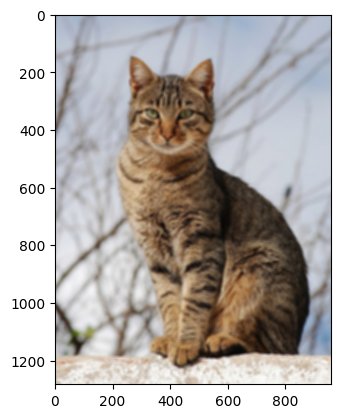

In [5]:
img2 = cv2.blur(img, (11,11))
TranDaiPhat.imshow(img2)

## 2. Sử dụng Gaussian Filter # Lưu ý: kích thước bộ lọc là số lẻ.

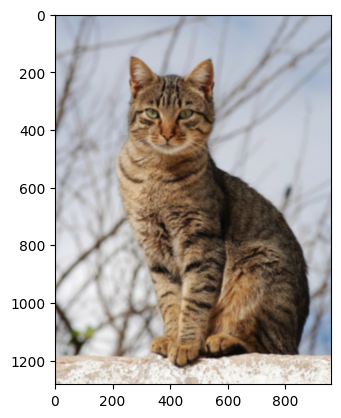

In [6]:
img3 = cv2.GaussianBlur(img, (11,11), 0)
TranDaiPhat.imshow(img3)

## 3. Sử dụng Median Filter 

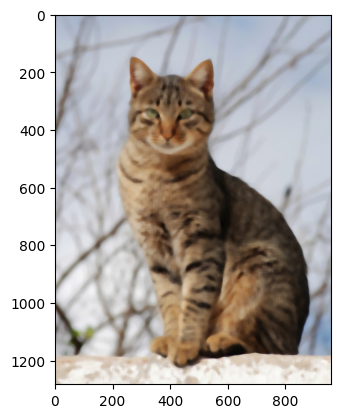

In [7]:
img3 = cv2.medianBlur(img, 15, 0)
TranDaiPhat.imshow(img3)

## 4. Kiểm tra lại các bộ lọc trên với hai hình ảnh pepper noise dưới đây: 
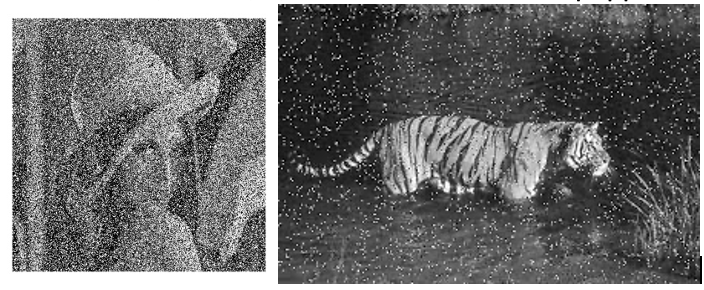

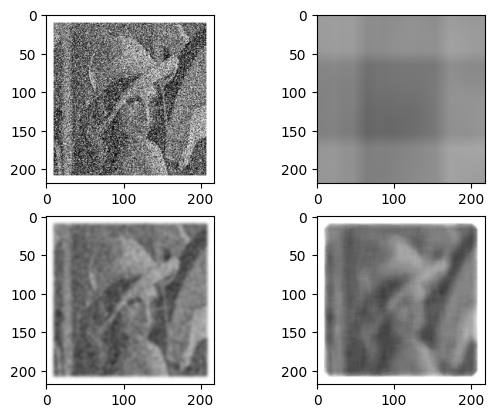

In [8]:
img_pepper01 = cv2.imread('pepper_noise01.png')
img_pepper01 = img_pepper01[:,:,::-1]
TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img_pepper01)

img_pepper01a = cv2.blur(img_pepper01, (110,110))
TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(img_pepper01a)

img_pepper01b = cv2.GaussianBlur(img_pepper01, (11,11), 0)
TranDaiPhat.subplot(2, 2, 3)
TranDaiPhat.imshow(img_pepper01b)

img_pepper01c = cv2.medianBlur(img_pepper01, 15, 0)
TranDaiPhat.subplot(2, 2, 4)
TranDaiPhat.imshow(img_pepper01c)

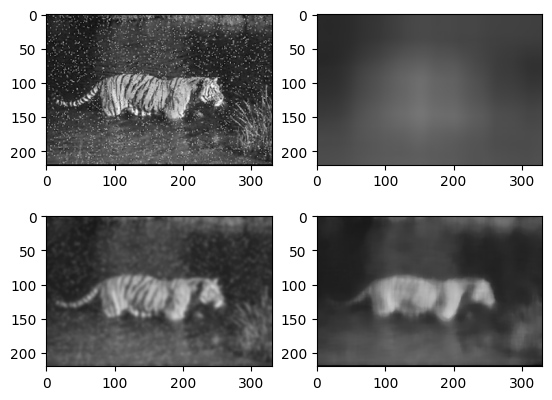

In [ ]:
img_pepper02 = cv2.imread('pepper_noise02.png')
img_pepper02 = img_pepper02[:,:,::-1]
TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img_pepper02)

img_pepper02a = cv2.blur(img_pepper02, (110,110))
TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(img_pepper02a)

img_pepper02b = cv2.GaussianBlur(img_pepper02, (11,11), 0)
TranDaiPhat.subplot(2, 2, 3)
TranDaiPhat.imshow(img_pepper02b)

img_pepper02c = cv2.medianBlur(img_pepper02, 15, 0)
TranDaiPhat.subplot(2, 2, 4)
TranDaiPhat.imshow(img_pepper02c)

## 5. Có nhận xét gì về các kích thước filter. 

- Filter phải ma trận hoặc kích thước lẻ 3x3, 5x5, 11x11, ...

- Kích thước phải nhỏ và vừa tránh làm quá mờ ảnh.

## 6. Thực hành với Cân bằng sáng - equalizeHist, để cân bằng sáng, trước hết ta chuyển ảnh trắng đen (nếu có) sang ảnh màu. 

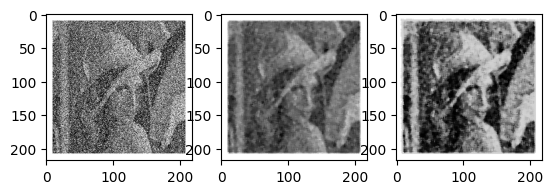

In [62]:
img = cv2.imread('pepper_noise01.png')
blur = cv2.medianBlur(img, 5)
gray_blur = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
ehist = cv2.equalizeHist(gray_blur)
TranDaiPhat.subplot(131)
TranDaiPhat.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
TranDaiPhat.subplot(132)
TranDaiPhat.imshow(gray_blur, cmap='gray')
TranDaiPhat.subplot(133)
TranDaiPhat.imshow(ehist, cmap='gray')

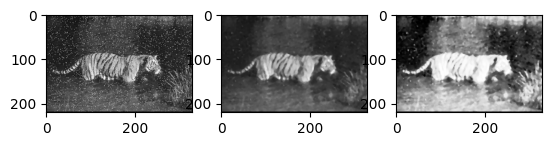

In [16]:
img = cv2.imread('pepper_noise02.png')
blur = cv2.medianBlur(img, 5)
gray_blur = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
ehist = cv2.equalizeHist(gray_blur)
TranDaiPhat.subplot(131)
TranDaiPhat.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
TranDaiPhat.subplot(132)
TranDaiPhat.imshow(gray_blur, cmap='gray')
TranDaiPhat.subplot(133)
TranDaiPhat.imshow(ehist, cmap='gray')

## 7. Bài tập trên lớp lý thuyết: FILTER bằng các phép toán số học và logic Given two images as follow (with different sizes: 193x157 and 194x160) 


### a. Crop two images to size 190x155

In [ ]:
# ép ảnh exT3_01.jpg về kích thước 193x157 và exT3_02.jpg về kích thước 194x160
from PIL import Image

try:
    img1 = Image.open('exT3_01.jpg')
    img1_resized = img1.resize((193, 157))
    
    if img1_resized.mode == 'RGBA':
        img1_resized = img1_resized.convert('RGB')
        
    img1_resized.save('exT3_01_resized.jpg')
    print("Đã ép ảnh exT3_01.jpg về kích thước 193x157")
except FileNotFoundError:
    print("Không tìm thấy file exT3_01.jpg")

try:
    img2 = Image.open('exT3_02.jpg')
    img2_resized = img2.resize((194, 160))
    
    if img2_resized.mode == 'RGBA':
        img2_resized = img2_resized.convert('RGB')
        
    img2_resized.save('exT3_02_resized.jpg')
    print("Đã ép ảnh exT3_02.jpg về kích thước 194x160")
except FileNotFoundError:
    print("Không tìm thấy file exT3_02.jpg")

Đã ép ảnh exT3_01.jpg về kích thước 193x157
Đã ép ảnh exT3_02.jpg về kích thước 194x160


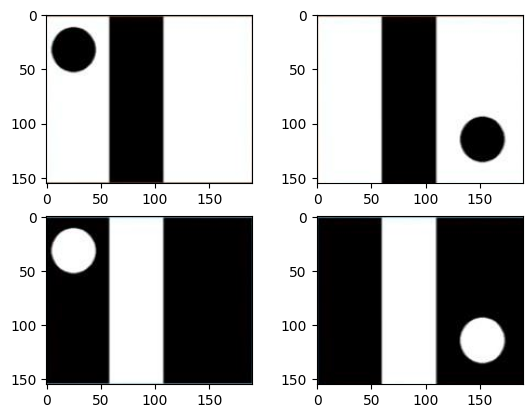

In [43]:
img1 = cv2.imread('exT3_01_resized.jpg')
img2 = cv2.imread('exT3_02_resized.jpg')
img1 = img1[:155,1:191]
img2 = img2[:155,:190]
inv_img1 = cv2.bitwise_not(img1)
inv_img2 = cv2.bitwise_not(img2)

TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img1)
TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(img2)
TranDaiPhat.subplot(2, 2, 3)
TranDaiPhat.imshow(inv_img1)
TranDaiPhat.subplot(2, 2, 4)
TranDaiPhat.imshow(inv_img2)

### b. Transform images to negative ones.

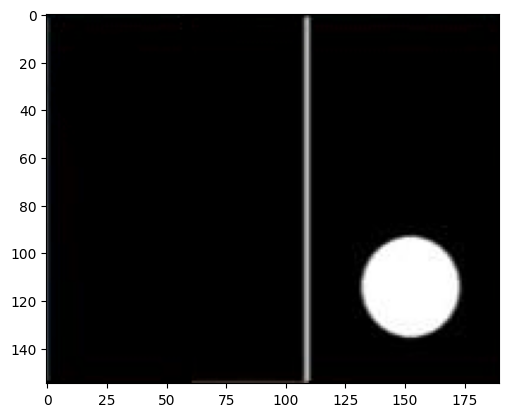

In [44]:
TranDaiPhat.imshow(cv2.subtract(inv_img2, inv_img1))

### c. Process to have an image which has only the “ball” Nếu vẫn còn xuất hiện các vạch trắng, cách khắc phục như thế nào?


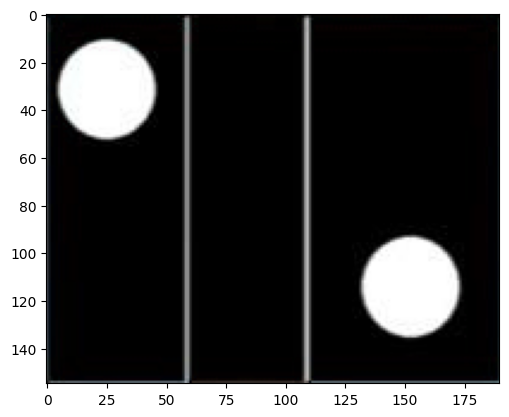

In [46]:
TranDaiPhat.imshow(cv2.absdiff(inv_img1, inv_img2))

## 1. Sử dụng Backward, forward, central gradient để lọc ảnh. 

Text(0.5, 1.0, 'Central Gradient')

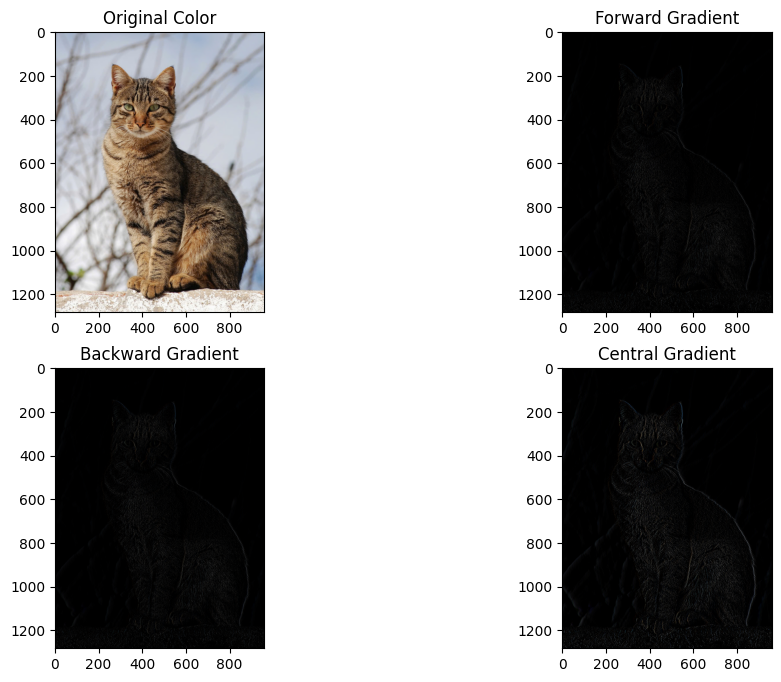

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as TranDaiPhat

img = cv2.imread('cat.jpg')
img = img[:, :, ::-1]

kernel_forward = np.array([[0, -1, 1]], dtype=np.float32)
kernel_backward = np.array([[-1, 1, 0]], dtype=np.float32)
kernel_central = np.array([[-1, 0, 1]], dtype=np.float32)

grad_forward = cv2.filter2D(img, cv2.CV_64F, kernel_forward)
grad_backward = cv2.filter2D(img, cv2.CV_64F, kernel_backward)
grad_central = cv2.filter2D(img, cv2.CV_64F, kernel_central)

grad_forward = np.clip(grad_forward, 0, 255).astype(np.uint8)
grad_backward = np.clip(grad_backward, 0, 255).astype(np.uint8)
grad_central = np.clip(grad_central, 0, 255).astype(np.uint8)

TranDaiPhat.figure(figsize=(12, 8))

TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img)
TranDaiPhat.title('Gốc')

TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(grad_forward)
TranDaiPhat.title('Forward Gradient')

TranDaiPhat.subplot(2, 2, 3)
TranDaiPhat.imshow(grad_backward)
TranDaiPhat.title('Backward Gradient')

TranDaiPhat.subplot(2, 2, 4)
TranDaiPhat.imshow(grad_central)
TranDaiPhat.title('Central Gradient')


## 2. Sử dụng Finite difference filter để lọc ảnh nhiễu. 

Text(0.5, 1.0, 'Finite Difference')

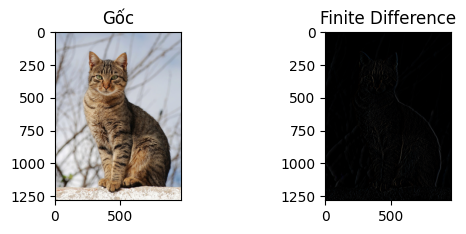

In [ ]:
img = cv2.imread('cat.jpg')
img = img[:, :, ::-1] 

img_smooth = cv2.GaussianBlur(img, (5, 5), 0)
kernel_x = np.array([[-1, 0, 1]], dtype=np.float32)
grad_x = cv2.filter2D(img_smooth, cv2.CV_64F, kernel_x)
grad_x = np.clip(grad_x, 0, 255).astype(np.uint8)

TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img)
TranDaiPhat.title('Gốc')

TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(grad_x)
TranDaiPhat.title('Finite Difference')


## 3. Sử dụng Gaussian filter để lọc ảnh. 

Text(0.5, 1.0, 'Gaussian Filter')

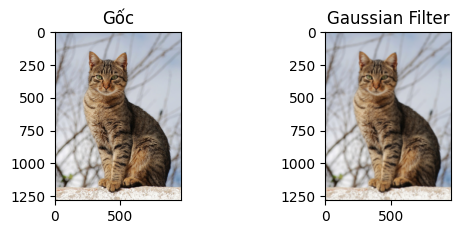

In [60]:
img = cv2.imread('cat.jpg')
img = img[:, :, ::-1]

img_blur_15 = cv2.GaussianBlur(img, (15, 15), 0)

TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img)
TranDaiPhat.title('Gốc')

TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(img_blur_15)
TranDaiPhat.title('Gaussian Filter')


## 4. Sử dụng Sobel detector để xác định biên của ảnh. 

Text(0.5, 1.0, 'Sobel Detector')

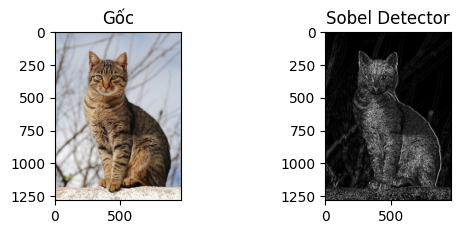

In [59]:
img = cv2.imread('cat.jpg')
img = img[:, :, ::-1] 

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobelx = np.clip(np.abs(sobelx), 0, 255).astype(np.uint8)

TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img)
TranDaiPhat.title('Gốc')

TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(sobelx, cmap='gray')
TranDaiPhat.title('Sobel Detector')



## 5. Sử dụng Canny edge detector để xác định các cạnh góc ảnh. 

Text(0.5, 1.0, 'Canny Edge Detector')

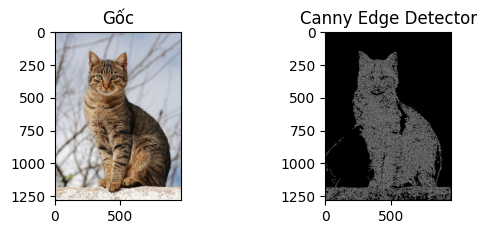

In [58]:
img = cv2.imread('cat.jpg')
img_rgb = img[:, :, ::-1] 

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gray, 50, 150)

TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img_rgb)
TranDaiPhat.title('Gốc')

TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(canny, cmap='gray')
TranDaiPhat.title('Canny Edge Detector')

## 6. Sử dụng Hough transform để xác định các đường thẳng trong ảnh. 

Text(0.5, 1.0, 'Hough Transform')

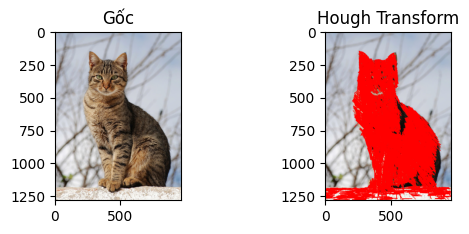

In [57]:
img = cv2.imread('cat.jpg')
img_rgb = img[:, :, ::-1] 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)

line_image = img_rgb.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 3)


TranDaiPhat.subplot(2, 2, 1)
TranDaiPhat.imshow(img_rgb)
TranDaiPhat.title('Gốc')

TranDaiPhat.subplot(2, 2, 2)
TranDaiPhat.imshow(line_image)
TranDaiPhat.title('Hough Transform')

